# The price moves: second-order shadow prices on an AC network

A shadow price is a derivative, and notebook 40 made the point that it has a
**range** — it is the slope of the value function, it holds while the active
set holds, and it expires. Notebook 41 took the primal half of the same
back-solve and turned it into a *plan*: $\mathrm dx^\star/\mathrm dp$, what to
change when the parameter moves.

This notebook takes the **dual** half on a model where the question is
someone's job. A 250 MW data center wants to interconnect at a bus. The
locational marginal price (LMP) at that bus is the shadow price of its power
balance, and the first-order answer — "the LMP is $41.79/MWh, so serving
250 MW costs $10,447/h" — is wrong by 17%, because the LMP is not a constant.
$\mathrm d\lambda/\mathrm dP$ is the rate at which it moves, and it is
**piecewise**. Two of its breakpoints sit 1.9 MW apart and bound a pricing
regime no practical sweep would resolve; another is a transmission line
reaching its thermal limit, where the rate jumps 2.2x, the price at the far
end of the system stops moving altogether, and the network splits into two
pricing regions.

Three things this adds to 40 and 41:

* the model is a genuine **nonlinear** AC optimal power flow, not a QP, so
  the quadratic value model is a real second-order approximation rather than
  an identity, and the residual is third-order;
* every AC-OPF fixes its slack-bus angle, which makes the factor's index
  space differ from the model's **on every power system there is** — the
  trap notebook 40's bakery could not reach;
* one of the breakpoints is a limit written as a **constraint row**
  rather than a variable bound, which is a different object inside the
  sensitivity layer and reads `kind='constraint'` in the report.

The last section is the honest scorecard against re-solving on a grid, which
is what this actually competes with.

In [1]:
import platform, subprocess, time
import importlib.metadata as meta
import numpy as np
import matplotlib.pyplot as plt
import pounce
from pounce.sensitivity import (
    SensSession, NlBridge, solution_report, active_set_changes,
)

SOURCE_COMMIT = subprocess.run(
    ["git", "rev-parse", "HEAD"], capture_output=True, text=True).stdout.strip()
print(f"python        {platform.python_version()}")
print(f"pounce-solver {meta.version('pounce-solver')}")
print(f"commit        {SOURCE_COMMIT[:12]}")

plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.3})

python        3.12.11
pounce-solver 0.11.0
commit        a8ba895be9e0


## 1. A five-bus network

Five buses, six branches, three generators, all per-unit on a 100 MVA base.
The data is chosen so that the events above happen in that order as
load at bus 5 grows; nothing about the method depends on the particular
numbers.

* **G1** at bus 1 is the swing machine: big, mid-priced, and marginal almost
  everywhere.
* **G2** at bus 2 is the cheap unit, and it has a **170 MW nameplate
  rating** it reaches early.
* **G3** at bus 5 is an expensive local peaker, off at the base point.

Costs are quadratic — the ordinary form of a generator bid curve, and the
reason the prices here decay smoothly instead of stepping. Section 6 of
notebook 40 spells out why a purely linear cost gives a staircase instead.

In [2]:
BASE  = 100.0                          # MVA base
NB    = 5
SLACK = 0
GB    = [0, 1, 4]                      # buses carrying a generator
#         a $/MWh   b $/MWh^2   Pmax MW   Qmin    Qmax
GEN = [(   30.0,     0.050,      400.0,  -200.0,  200.0),    # G1  bus 1
       (   15.0,     0.085,      170.0,  -150.0,  150.0),    # G2  bus 2  <- the rating
       (   45.0,     0.080,      250.0,  -150.0,  150.0)]    # G3  bus 5
#      i  k     r       x      b_c    Smax MVA
BR = [(0, 1, 0.008, 0.060, 0.06, 400.0),
      (0, 3, 0.010, 0.080, 0.07, 240.0),
      (1, 2, 0.012, 0.090, 0.08, 240.0),
      (2, 3, 0.015, 0.110, 0.09, 180.0),
      (3, 4, 0.010, 0.070, 0.06, 140.0),
      (1, 4, 0.020, 0.140, 0.10, 120.0)]   # <- the one that congests

PD     = np.array([0.0, 0.0, 100.0, 120.0, 0.0]) / BASE   # bus 5 is the parameter
QSCALE = np.tan(np.arccos(0.95))                          # 0.95 pf lagging
VLO, VHI = 0.95, 1.05

def ybus():
    Y = np.zeros((NB, NB), complex)
    for i, k, r, x, bc, _ in BR:
        y = 1.0 / complex(r, x)
        Y[i, i] += y + 1j * bc / 2
        Y[k, k] += y + 1j * bc / 2
        Y[i, k] -= y
        Y[k, i] -= y
    return Y

Y = ybus(); G, B = Y.real, Y.imag

# variable layout, in full-x (model) order
TH   = list(range(0, NB))
V    = list(range(NB, 2 * NB))
PG   = list(range(2 * NB, 2 * NB + 3))
QG   = list(range(2 * NB + 3, 2 * NB + 6))
DVAR = 2 * NB + 6                       # the load at bus 5 -- the parameter
N    = DVAR + 1

print(f"{N} variables, {NB} buses, {len(BR)} branches, {len(GB)} generators")
print(f"base load: bus 3 {PD[2]*BASE:.0f} MW, bus 4 {PD[3]*BASE:.0f} MW, "
      f"bus 5 = the parameter")

17 variables, 5 buses, 6 branches, 3 generators
base load: bus 3 100 MW, bus 4 120 MW, bus 5 = the parameter


### The parameter is a pinned row

Same device as notebooks 40 and 41: the load at bus 5 is carried as an
ordinary **variable** `d`, pinned by an equality row `pin_load: d = d0`.
Perturbing that row's right-hand side is what "add load at bus 5" means to
the sensitivity layer, and it is why `d` shows up with
$\mathrm dd/\mathrm dd = 1$ in every column below.

The rest is a textbook polar-coordinate AC-OPF: real and reactive balance at
each bus, apparent-power limits at both ends of every branch, voltage
magnitudes boxed in $[0.95, 1.05]$, and the slack-bus angle **fixed at
zero** — which is the detail section 5 comes back to.

In [3]:
def build(d0):
    v  = pounce.NlExpr.vars(N)
    th, vm = [v[i] for i in TH], [v[i] for i in V]
    pg, qg = [v[i] for i in PG], [v[i] for i in QG]
    d  = v[DVAR]

    def injection(i):
        P = Q = None
        for k in range(NB):
            if G[i, k] == 0.0 and B[i, k] == 0.0:
                continue
            dth = th[i] - th[k]
            c, s = pounce.NlExpr.cos(dth), pounce.NlExpr.sin(dth)
            tp = vm[k] * (G[i, k] * c + B[i, k] * s)
            tq = vm[k] * (G[i, k] * s - B[i, k] * c)
            P = tp if P is None else P + tp
            Q = tq if Q is None else Q + tq
        return vm[i] * P, vm[i] * Q

    cons, gl, gu, rows = [], [], [], []
    cons.append(d); gl.append(d0); gu.append(d0); rows.append("pin_load")

    gmap = {b: j for j, b in enumerate(GB)}
    for i in range(NB):
        Pi, Qi = injection(i)
        pd = d          if i == 4 else pounce.NlExpr.const_(PD[i])
        qd = d * QSCALE if i == 4 else pounce.NlExpr.const_(PD[i] * QSCALE)
        e, f = -pd - Pi, -qd - Qi
        if i in gmap:
            e = e + pg[gmap[i]]
            f = f + qg[gmap[i]]
        cons += [e, f]; gl += [0.0, 0.0]; gu += [0.0, 0.0]
        rows += [f"pbal{i+1}", f"qbal{i+1}"]

    for (i, k, r, x, bc, smax) in BR:               # S^2 <= Smax^2, both ends
        y = 1.0 / complex(r, x); g_, b_ = y.real, y.imag
        for (a, z) in ((i, k), (k, i)):
            dth = th[a] - th[z]
            c, s = pounce.NlExpr.cos(dth), pounce.NlExpr.sin(dth)
            Pf =  g_ * vm[a] * vm[a] - vm[a] * vm[z] * (g_ * c + b_ * s)
            Qf = -(b_ + bc / 2) * vm[a] * vm[a] - vm[a] * vm[z] * (g_ * s - b_ * c)
            cons.append(Pf * Pf + Qf * Qf)
            gl.append(-1e19); gu.append((smax / BASE) ** 2)
            rows.append(f"s{a+1}_{z+1}")

    obj = None
    for j, b in enumerate(GB):                      # $/h, with Pg in MW
        a_, bq = GEN[j][0], GEN[j][1]
        mw = pg[j] * BASE
        t  = a_ * mw + bq * mw * mw
        obj = t if obj is None else obj + t

    xl = [-np.pi] * NB + [VLO] * NB + [0.0] * 3 + [g[3] / BASE for g in GEN] + [-1e19]
    xu = [ np.pi] * NB + [VHI] * NB + [g[2] / BASE for g in GEN] \
                                    + [g[4] / BASE for g in GEN] + [1e19]
    xl[SLACK] = xu[SLACK] = 0.0                     # the slack-bus angle is FIXED
    x0   = [0.0] * NB + [1.0] * NB + [1.0, 1.0, 0.5] + [0.0] * 3 + [d0]
    vname = ([f"th{i+1}" for i in range(NB)] + [f"V{i+1}" for i in range(NB)]
             + [f"Pg{b+1}" for b in GB] + [f"Qg{b+1}" for b in GB] + ["d"])
    return pounce.build_nl_problem(
        n=N, objective=obj, constraints=cons, g_l=gl, g_u=gu,
        x_l=xl, x_u=xu, x0=x0, var_names=vname, con_names=rows), vname, rows


NSOLVES = 0

def solve(load_mw):
    """Solve the AC-OPF with `load_mw` at bus 5; return (session, info, rows)."""
    global NSOLVES
    NSOLVES += 1
    nl, vname, rows = build(load_mw / BASE)
    prob = pounce.Problem(nl.n, nl.m, NlBridge(nl),
                          lb=nl.x_l, ub=nl.x_u, cl=nl.g_l, cu=nl.g_u)
    prob.add_option("bound_relax_factor", 0.0)   # required by the activity accessors
    prob.add_option("print_level", 0)
    solver = pounce.Solver(prob)
    x, info = solver.solve(np.asarray(nl.x0))
    sess = SensSession(nl, solver, vname, rows, pins={"load": 0})
    sess.base_x, sess.base_obj = np.asarray(x, float), float(info["obj_val"])
    return sess, info, rows


def lmp(info, rows, bus):
    """LMP at `bus`, in $/MWh: the power-balance multiplier, sign- and unit-fixed."""
    return -np.asarray(info["mult_g"])[rows.index(f"pbal{bus+1}")] / BASE


def cost(info):
    return float(info["obj_val"])

## 2. The base case

40 MW of load at bus 5 today. Solve, and read the five LMPs off the
power-balance multipliers.

The check that this is really an LMP and not a number with the right units:
at a bus whose generator is **interior** — off both its limits — the LMP must
equal that generator's marginal cost exactly, because the last MW came from
there. G1 is interior, so $\lambda_1 = 30 + 2(0.05)P_{g1}$, to machine
precision or the sign convention is wrong.

In [4]:
D0   = 40.0        # MW of load at bus 5 today
SPAN = 260.0       # MW the interconnection study asks about

sess0, info0, ROWS = solve(D0)
x0   = sess0.base_x
L0   = np.array([lmp(info0, ROWS, i) for i in range(NB)])
PG0  = x0[PG] * BASE
C0   = cost(info0)

print(f"status {info0['status']}    production cost  ${C0:,.1f}/h\n")
print(f"{'':6s}{'V (pu)':>9s}{'angle deg':>11s}{'gen MW':>10s}{'LMP $/MWh':>12s}")
for i in range(NB):
    g = f"{PG0[GB.index(i)]:10.1f}" if i in GB else f"{'--':>10s}"
    print(f"bus {i+1:<2d}{x0[V[i]]:9.4f}{np.degrees(x0[TH[i]]):8.2f}{g}{L0[i]:12.3f}")

mc1 = GEN[0][0] + 2 * GEN[0][1] * PG0[0]
print(f"\nG1 is interior at {PG0[0]:.2f} MW; its marginal cost is {mc1:.6f} $/MWh")
print(f"LMP at bus 1                                    {L0[0]:.6f} $/MWh")
assert info0["status"] == 0
assert abs(mc1 - L0[0]) < 1e-6, "the LMP is not the marginal cost -- sign or units"
assert PG0[1] < GEN[1][2] - 1.0, "G2 is already capped -- no first event to find"
print("\nthe multipliers are LMPs")

status 0    production cost  $8,184.8/h

         V (pu)  angle deg    gen MW   LMP $/MWh
bus 1    1.0500    0.00     110.0      41.001
bus 2    1.0500   -0.03     152.9      40.987
bus 3    1.0194   -4.62        --      41.923
bus 4    1.0264   -4.52        --      41.884
bus 5    1.0426   -4.09       0.0      41.787

G1 is interior at 110.01 MW; its marginal cost is 41.001189 $/MWh
LMP at bus 1                                    41.001189 $/MWh

the multipliers are LMPs


## 3. The first-order quote

The LMP at bus 5 is \$41.79/MWh. The naive interconnection quote is that
number times the megawatts:

$$\Delta C \;\approx\; \lambda_5 \,\Delta P .$$

This is exactly the marginal-value reasoning of notebook 40 section 2, and it
fails the same way — but here the failure is monotone and large, because
serving more load pushes every generator up its own bid curve.

In [5]:
TARGETS = [20.0, 45.0, 100.0, 150.0, 200.0, 230.0, 250.0]
TRUE = {g: cost(solve(D0 + g)[1]) - C0 for g in TARGETS}

print(f"{'add MW':>8s}{'true $/h':>13s}{'1st order':>13s}{'error':>10s}")
for g in TARGETS:
    lin = L0[4] * g
    print(f"{g:8.0f}{TRUE[g]:13,.1f}{lin:13,.1f}{(lin - TRUE[g]) / TRUE[g]:10.1%}")
print(f"\nthe quote for the full {TARGETS[-1]:.0f} MW is "
      f"${L0[4] * TARGETS[-1]:,.0f}/h against a true "
      f"${TRUE[TARGETS[-1]]:,.0f}/h -- short by "
      f"${TRUE[TARGETS[-1]] - L0[4] * TARGETS[-1]:,.0f}/h")

  add MW     true $/h    1st order     error
      20        850.4        835.7     -1.7%
      45      1,955.0      1,880.4     -3.8%
     100      4,536.2      4,178.7     -7.9%
     150      7,061.2      6,268.1    -11.2%
     200      9,758.0      8,357.5    -14.4%
     230     11,459.5      9,611.1    -16.1%
     250     12,646.1     10,446.8    -17.4%

the quote for the full 250 MW is $10,447/h against a true $12,646/h -- short by $2,199/h


## 4. $\mathrm d\lambda/\mathrm dP$: the price has a slope

The value function's first derivative is the price; its **second** derivative
is the rate the price moves at. `SensSession.column(pin)` returns the
derivative of the whole KKT solution with respect to that pin's right-hand
side — primal *and* dual — from one back-solve against the factor the solve
already built. `mult_entry(row)` says where a given row's multiplier lives in
it.

Two conversions, and getting either wrong is silent:

* **sign** — the LMP is $-\mu/100$ for this row orientation, so
  $\mathrm d\lambda/\mathrm dP$ inherits the same minus;
* **units** — the column is per unit of the *pin's* right-hand side, which is
  in per-unit MW, so $\$/\mathrm{MWh}$ per MW picks up a second $1/100$.

The check is a central difference of the LMP across two re-solves. It should
agree to solver tolerance, and it does, at every bus.

In [6]:
col0 = sess0.column(0)          # one back-solve; cached on the session

def dlmp_dP(sess, bus):
    """d(LMP at `bus`)/d(load at bus 5), in $/MWh per MW."""
    return -float(sess.column(0)[sess.mult_entry(f"pbal{bus+1}")]) / BASE / BASE

print(f"{'':6s}{'LMP $/MWh':>12s}{'dLMP/dP':>13s}{'central FD':>13s}{'rel err':>10s}")
DL0, h = np.zeros(NB), 1e-3
for i in range(NB):
    an = dlmp_dP(sess0, i)
    fd = (lmp(*solve(D0 + h)[1:], i) - lmp(*solve(D0 - h)[1:], i)) / (2 * h)
    DL0[i] = an
    print(f"bus {i+1:<2d}{L0[i]:12.3f}{an:+13.6f}{fd:+13.6f}{abs(an - fd) / abs(fd):10.1e}")
    assert abs(an - fd) / abs(fd) < 1e-5, f"bus {i+1}: dlam/dP disagrees with a re-solve"
print("\nevery bus agrees with a re-solve to solver tolerance")

         LMP $/MWh      dLMP/dP   central FD   rel err
bus 1       41.001    +0.063775    +0.063775   9.4e-09
bus 2       40.987    +0.064864    +0.064864   1.6e-08
bus 3       41.923    +0.067500    +0.067500   2.1e-08
bus 4       41.884    +0.068837    +0.068837   3.6e-08
bus 5       41.787    +0.073089    +0.073089   2.7e-08

every bus agrees with a re-solve to solver tolerance


With the rate in hand the quote gets its second-order term,

$$\Delta C \;=\; \lambda_5\,\Delta P \;+\; \tfrac12
\frac{\mathrm d\lambda_5}{\mathrm dP}\,\Delta P^2 ,$$

which for a **QP** under linear constraints is exact while the active set
holds — that is notebook 40 section 7. This model is not a QP: the power flow
equations are trigonometric, so the value function is genuinely nonlinear and
the term above is an approximation whose residual is third-order. What that
buys is worth measuring rather than assuming.

In [7]:
print(f"{'add MW':>8s}{'true $/h':>13s}{'1st order':>13s}{'err':>9s}"
      f"{'2nd order':>13s}{'err':>9s}")
for g in TARGETS:
    lin  = L0[4] * g
    quad = L0[4] * g + 0.5 * DL0[4] * g * g
    print(f"{g:8.0f}{TRUE[g]:13,.1f}{lin:13,.1f}{(lin - TRUE[g]) / TRUE[g]:9.1%}"
          f"{quad:13,.1f}{(quad - TRUE[g]) / TRUE[g]:9.1%}")

g = TARGETS[-1]
e1 = abs(L0[4] * g - TRUE[g])
e2 = abs(L0[4] * g + 0.5 * DL0[4] * g * g - TRUE[g])
print(f"\nover the full {g:.0f} MW the second-order term removes "
      f"{1 - e2 / e1:.1%} of the first-order error,")
print(f"from ${e1:,.0f}/h short to ${e2:,.0f}/h over -- for one back-solve.")

  add MW     true $/h    1st order      err    2nd order      err
      20        850.4        835.7    -1.7%        850.4    -0.0%
      45      1,955.0      1,880.4    -3.8%      1,954.4    -0.0%
     100      4,536.2      4,178.7    -7.9%      4,544.2     0.2%
     150      7,061.2      6,268.1   -11.2%      7,090.3     0.4%
     200      9,758.0      8,357.5   -14.4%      9,819.2     0.6%
     230     11,459.5      9,611.1   -16.1%     11,544.3     0.7%
     250     12,646.1     10,446.8   -17.4%     12,730.8     0.7%

over the full 250 MW the second-order term removes 96.1% of the first-order error,
from $2,199/h short to $85/h over -- for one back-solve.


## 5. The index-space trap every AC-OPF walks into

The same column carries the primal half — notebook 41's delta planning
vector. Reading it is where a power-systems model differs from a bakery.

An AC-OPF **fixes the slack-bus angle**, here `th1` with
`x_l == x_u == 0`. Under the default `fixed_variable_treatment=make_parameter`
the solve removes such a variable, so the KKT factor's `x` block is one
shorter than the model's variable list, and every variable after the fixed one
sits one row earlier in the factor than its model index. `var_entry(name)`
returns the **full-x** (model) column; the factor is in **var-x**. Indexing one
with the other returns a *neighbouring* variable's sensitivity — a plausible
number, correctly signed, about the wrong variable. That is gh#450, and
`SensSession.primal_row` exists to route around it.

The bakery in notebook 40 has no fixed variable, so the two spaces coincide
there and the bug is unreachable. **Every** power system has a slack bus, so
here it is unavoidable. The table shows both readings against a finite
difference.

In [8]:
hmw = 1e-3                          # MW; the column is per unit of the PIN's rhs,
fd  = (solve(D0 + hmw)[0].base_x    # which is in per-unit MW, hence the /BASE
       - solve(D0 - hmw)[0].base_x) / (2 * hmw / BASE)

VARX_NAME = {}                       # which variable actually owns each var-x row
for o in sess0.var_names:
    try:
        VARX_NAME[sess0.primal_row(sess0.var_entry(o), o)] = o
    except ValueError:
        pass                             # the fixed variable owns no row at all

print(f"{'variable':>9s}{'full-x':>8s}{'var-x':>7s}{'FD dx/dP':>12s}"
      f"{'via primal_row':>16s}{'via var_entry':>15s}{'':4s}{'reads as':>9s}")
wrong = 0
for nm in ["th2", "V5", "Pg1", "Pg2", "Qg5", "d"]:
    fi   = sess0.var_entry(nm)
    vi   = sess0.primal_row(fi, nm)
    good = float(col0[vi])
    bad  = float(col0[fi])
    tol  = 1e-6 * max(1.0, abs(fd[fi]))
    assert abs(good - fd[fi]) < tol, f"{nm}: primal_row disagrees with a re-solve"
    wrong += abs(bad - fd[fi]) > tol
    nbr = VARX_NAME.get(fi, "?")
    print(f"{nm:>9s}{fi:8d}{vi:7d}{fd[fi]:12.5f}{good:16.5f}{bad:15.5f}{'':4s}{nbr:>9s}")

print(f"\nprimal_row reproduces the re-solve at all 6; var_entry is wrong at "
      f"{wrong} of 6,")
print("and each wrong number is the correct sensitivity of the variable named last.")
try:
    sess0.primal_row(sess0.var_entry("th1"), "th1")
except ValueError as e:
    print(f"\nasking for the fixed variable itself is refused, by name:\n  {e}")

 variable  full-x  var-x    FD dx/dP  via primal_row  via var_entry     reads as
      th2       1      0    -0.01076        -0.01076       -0.02078          th3
       V5       9      8    -0.00644        -0.00644        0.63775          Pg1
      Pg1      10      9     0.63775         0.63775        0.38155          Pg2
      Pg2      11     10     0.38155         0.38155        0.00000          Pg5
      Qg5      15     14     0.41217         0.41217        1.00000            d
        d      16     15     1.00000         1.00000        0.00589            ?

primal_row reproduces the re-solve at all 6; var_entry is wrong at 6 of 6,
and each wrong number is the correct sensitivity of the variable named last.

asking for the fixed variable itself is refused, by name:
  th1: th1 was removed from the solve as a fixed variable (its bounds are equal), so it has no row in the KKT factor and no sensitivity. Give it distinct bounds to keep it in the solve.


## 6. How far does the price hold?

The second-order model is only good while the active set is. `solution_report`
runs the ratio test over the same factor: it propagates
$\partial x^\star/\partial P$, asks which coordinate reaches a bound first,
and returns the fraction of the requested step that survives — plus **the name
of what ends it**.

The alternative, with no sensitivity layer at all, is to bisect on re-solves.
Both are run below.

In [9]:
def bisect_event(pred, lo, hi, n=50):
    for _ in range(n):
        m = 0.5 * (lo + hi)
        lo, hi = (m, hi) if pred(m) else (lo, m)
    return 0.5 * (lo + hi)

n0 = NSOLVES
t  = time.perf_counter()
T_PG2 = bisect_event(                      # G2 still off its rating?
    lambda d: GEN[1][2] - solve(d)[0].base_x[PG[1]] * BASE > 1e-4, D0, D0 + SPAN)
T_PG5 = bisect_event(                      # G3 still shut down?
    lambda d: solve(d)[0].base_x[PG[2]] * BASE < 1e-4, D0, D0 + SPAN)
t_bisect = (time.perf_counter() - t) / 2
E1 = T_PG2 - D0
print(f"bisection : G2 reaches its rating at {T_PG2:8.3f} MW"
      f"   {t_bisect:.2f} s, {(NSOLVES - n0) // 2} solves")
print(f"            G3 starts up          at {T_PG5:8.3f} MW   (a second event, "
      f"{T_PG2 - T_PG5:.2f} MW earlier)\n")

t = time.perf_counter()
rep = solution_report(sess0, [0], [SPAN / BASE])
t_ratio = time.perf_counter() - t
print(f"ratio test: holds for +{rep.alpha * SPAN:7.3f} MW -> {D0 + rep.alpha * SPAN:8.3f} MW"
      f"   ended by {rep.first} ({rep.first_kind})")
print(f"            {t_ratio * 1e3:.2f} ms, 0 extra solves, "
      f"{t_bisect / t_ratio:,.0f}x faster, off by {abs(D0 + rep.alpha * SPAN - T_PG2):.3f} MW\n")

t = time.perf_counter()
CH = active_set_changes(sess0, [0], [SPAN / BASE])
t_walk = time.perf_counter() - t
print(f"path walk : {t_walk * 1e3:.2f} ms, 0 extra solves")
for ch in CH:
    print(f"            +{ch.fraction * SPAN:7.3f} MW -> {D0 + ch.fraction * SPAN:8.3f} MW"
          f"   {ch.var:5s} {ch.bound:6s} {ch.action}")
w2 = next(c for c in CH if str(c.var) == "Pg2")
print(f"\nthe single ratio test misses G2's event by "
      f"{abs(D0 + rep.alpha * SPAN - T_PG2):.3f} MW; the walk misses it by "
      f"{abs(D0 + w2.fraction * SPAN - T_PG2):.3f} MW.")
assert rep.first_kind == "variable" and str(rep.first) == "Pg2"

bisection : G2 reaches its rating at   85.308 MW   0.14 s, 50 solves
            G3 starts up          at   83.402 MW   (a second event, 1.91 MW earlier)

ratio test: holds for + 44.904 MW ->   84.904 MW   ended by Pg2 (variable)
            0.46 ms, 0 extra solves, 293x faster, off by 0.404 MW

path walk : 0.79 ms, 0 extra solves
            + 43.956 MW ->   83.956 MW   Pg5   lower  leaves
            + 45.337 MW ->   85.337 MW   Pg2   upper  reaches
            + 87.644 MW ->  127.644 MW   V1    upper  reaches

the single ratio test misses G2's event by 0.404 MW; the walk misses it by 0.029 MW.


Each bisection cost 50 solves and returned a *number*. The two cheap
accessors cost a back-solve each and returned a number **and the reason**:
`Pg2`, a variable, at its upper bound. That naming is the part a grid sweep
cannot reproduce at any price — a sweep shows the cost curve bending, not
which of 17 variables and 23 rows bent it.

The gap between the two cheap answers is worth reading rather than averaging.
`solution_report`'s `alpha` is a **single** first-order ratio test fired from
the base point, and it is 0.4 MW short. That is not the model's nonlinearity:
`active_set_changes` walks the same direction on the same factor and lands
within 0.03 MW. The difference is that something happens on the way — G3
starts up 1.9 MW before G2 caps — and a single ratio test extrapolates
through it while the walk re-forms its direction at the breakpoint and
carries on.

Note also *which* event `alpha` reports. G3 starting up is a bound
**releasing**, and a primal ratio test is built to catch a coordinate
*reaching* a limit, so `first` names `Pg2` even though `Pg5` moves first.
That is notebook 40 section 8's point, on a network: the walk records both,
and their `action` field is what separates them.

## 7. The rate is piecewise

Between those two events is a regime 1.9 MW wide. Inside it three generators
are simultaneously marginal, so an extra megawatt is shared three ways and
the price moves *slowest* of anywhere in the study:

In [10]:
def flow_ratio(x, want="s2_5"):
    th, vm = x[TH], x[V]
    for (i, k, r, xr, bc, smax) in BR:
        y = 1.0 / complex(r, xr); g_, b_ = y.real, y.imag
        for (a, z) in ((i, k), (k, i)):
            if f"s{a+1}_{z+1}" != want:
                continue
            d = th[a] - th[z]; c, s = np.cos(d), np.sin(d)
            P =  g_ * vm[a] ** 2 - vm[a] * vm[z] * (g_ * c + b_ * s)
            Q = -(b_ + bc / 2) * vm[a] ** 2 - vm[a] * vm[z] * (g_ * s - b_ * c)
            return np.hypot(P, Q) * BASE / smax

E2 = bisect_event(lambda d: 1.0 - flow_ratio(solve(d)[0].base_x) > 1e-7, 150.0, 300.0)
E3 = bisect_event(lambda d: VHI - solve(d)[0].base_x[V[1]] < 1e-7, 270.0, 340.0)
EV = [(T_PG5, "G3 starts up",                 "variable bound releases"),
      (T_PG2, "G2 reaches its 170 MW rating", "variable bound activates"),
      (E2,    "line 2-5 reaches 120 MVA",     "constraint row activates"),
      (E3,    "V2 leaves its 1.05 ceiling",   "variable bound releases")]

GRID19 = [75.0, 82.0, 84.0, 84.8, 86.0, 100.0, 200.0, 266.0, 275.0, 290.0, 305.0]
print(f"{'load MW':>9s}{'dLMP5/dP':>12s}   marginal units")
prev = 0.0
for d in GRID19:
    for l, w, _ in EV:                       # events crossed since the last row
        if prev < l < d:
            print(f"{'':9s}{'':12s}   ---- {l:.2f} MW: {w} ----")
    sd = solve(d)[0]
    on = [f"G{k+1}" for k in range(3)
          if 1e-4 < sd.base_x[PG[k]] * BASE < GEN[k][2] - 1e-4]
    print(f"{d:9.1f}{dlmp_dP(sd, 4):+12.6f}   {'+'.join(on) or '(none)'}")
    prev = d

print(f"\n{'event':>32s}{'load MW':>10s}{'left':>11s}{'right':>11s}{'jump':>8s}")
for load, what, kind in EV:
    a = dlmp_dP(solve(load - 1.0)[0], 4)
    b = dlmp_dP(solve(load + 1.0)[0], 4)
    print(f"{what:>32s}{load:10.2f}{a:+11.6f}{b:+11.6f}{b / a:7.2f}x   {kind}")
r_in  = dlmp_dP(solve(0.5 * (T_PG5 + T_PG2))[0], 4)
r_out = dlmp_dP(solve(T_PG5 - 1.0)[0], 4)
print(f"\nthe three-marginal-unit regime is {T_PG2 - T_PG5:.2f} MW wide, and the price")
print(f"moves {1 - r_in / r_out:.0%} slower inside it than just below it. A 5 MW sweep grid")
print("has no sample in it at all.")

  load MW    dLMP5/dP   marginal units
     75.0   +0.074528   G1+G2
     82.0   +0.074822   G1+G2
                        ---- 83.40 MW: G3 starts up ----
     84.0   +0.051017   G1+G2+G3
     84.8   +0.051028   G1+G2+G3
                        ---- 85.31 MW: G2 reaches its 170 MW rating ----
     86.0   +0.067183   G1+G3
    100.0   +0.067394   G1+G3
    200.0   +0.068914   G1+G3
    266.0   +0.069929   G1+G3
                        ---- 269.99 MW: line 2-5 reaches 120 MVA ----
    275.0   +0.156991   G1+G3
    290.0   +0.159490   G1+G3
                        ---- 297.96 MW: V2 leaves its 1.05 ceiling ----
    305.0   +0.154414   G1+G3

                           event   load MW       left      right    jump
                    G3 starts up     83.40  +0.074839  +0.051023   0.68x   variable bound releases
    G2 reaches its 170 MW rating     85.31  +0.051021  +0.067187   1.32x   variable bound activates
        line 2-5 reaches 120 MVA    269.99  +0.069975  +0.154028   2.20x   const

The middle row is the one with a story. When line 2-5 saturates, the price at
bus 5 starts moving **2.2x faster** — and the price at bus 1, at the other end
of the constrained path, very nearly stops moving at all. The network has
split into two pricing regions, which is what congestion *is*, and the
second-order term is where it shows up first.

In [11]:
print(f"{'load MW':>9s}{'LMP1':>9s}{'LMP5':>9s}{'spread':>9s}"
      f"{'dLMP1/dP':>12s}{'dLMP5/dP':>12s}")
for d in [200.0, 250.0, 266.0, 268.5, 271.5, 280.0, 290.0]:
    s, i, r = solve(d)
    a, b = lmp(i, r, 0), lmp(i, r, 4)
    tag = "   <-- line 2-5 saturates here" if abs(d - E2) < 2.0 else ""
    print(f"{d:9.1f}{a:9.3f}{b:9.3f}{b - a:9.3f}"
          f"{dlmp_dP(s, 0):+12.6f}{dlmp_dP(s, 4):+12.6f}{tag}")
print(f"\nbelow {E2:.0f} MW the two prices track each other; above it bus 1 is frozen")
print("at its own marginal cost and every additional MW at bus 5 is priced by G3.")

  load MW     LMP1     LMP5   spread    dLMP1/dP    dLMP5/dP
    200.0   50.691   52.900    2.209   +0.059410   +0.068914
    250.0   53.659   56.365    2.706   +0.059296   +0.069682
    266.0   54.607   57.482    2.875   +0.059258   +0.069929
    268.5   54.756   57.657    2.901   +0.059252   +0.069967   <-- line 2-5 saturates here
    271.5   54.849   57.996    3.147   +0.003594   +0.154561   <-- line 2-5 saturates here
    280.0   54.865   59.331    4.465   +0.001005   +0.158513
    290.0   54.871   60.922    6.051   +0.000354   +0.159490

below 270 MW the two prices track each other; above it bus 1 is frozen
at its own marginal cost and every additional MW at bus 5 is priced by G3.


## 8. A limit written as a constraint row

Every breakpoint so far was a **variable bound**: a generator against its own
upper or lower limit, a number in the box. The next one is not. A branch's thermal limit is
$P_{ij}^2 + Q_{ij}^2 \le S_{\max}^2$ — a nonlinear function of four
variables, written as a row of $g$, with its limit bounding the row's
**slack** rather than any variable.

Those are different objects inside the sensitivity layer. A variable bound's
multiplier lives in the `z` blocks and constrains a row of the `x` block; a
row limit's lives in `v` and constrains a row of `s`. The ratio test has to
scan both to answer "what ends the range", and the report has to be able to
say which kind it found. Asked from a base point 44 MW short of the event:

In [12]:
base = E2 - 44.0
sb, ib, rb = solve(base)
repb = solution_report(sb, [0], [60.0 / BASE])
print(f"from {base:.1f} MW, looking 60 MW ahead:")
print(f"    holds for  +{repb.alpha * 60:.2f} MW  ->  {base + repb.alpha * 60:.2f} MW")
print(f"    ended by   {repb.first}   kind = {repb.first_kind}")
print(f"    truth      {E2:.2f} MW  (bisected, {50} solves)")
print(f"    error      {abs(base + repb.alpha * 60 - E2):.2f} MW "
      f"({abs(base + repb.alpha * 60 - E2) / E2:.2%})")
print()
print("active_set_changes over the same step:")
for ch in active_set_changes(sb, [0], [60.0 / BASE]):
    print(f"    +{ch.fraction * 60:7.2f} MW   {ch.var:6s} {ch.bound:6s} {ch.action}")
assert repb.first_kind == "constraint", "the row limit was not reported as a row"
print(f"\nkind='constraint', and the row is named: s2_5 is branch 2-5's "
      f"from-end flow.")

from 226.0 MW, looking 60 MW ahead:
    holds for  +46.03 MW  ->  272.02 MW
    ended by   s2_5   kind = constraint
    truth      269.99 MW  (bisected, 50 solves)
    error      2.03 MW (0.75%)

active_set_changes over the same step:
    +  46.03 MW   s2_5   upper  reaches

kind='constraint', and the row is named: s2_5 is branch 2-5's from-end flow.


`kind='constraint'` is not cosmetic. A limit written as a row had no entry in
the reach scan at all until gh#928 — no breakpoint it could be recorded as,
and a step that walked straight through it with an empty segment list. On a
power system that is the *common* case: generator ratings are variable
bounds, but every thermal limit, every interface limit and every voltage-angle
difference limit is a row.

## 9. The release a sweep does not find

Both events the ratio test *named* were a coordinate reaching a limit, which
is what a primal ratio test is built to see. The other kind is a constraint
that **releases**: its multiplier falls to zero and it lets go. Nothing reaches a
bound when that happens, and no amount of watching the primal variables
reveals it — you would have to already know which of them to watch.

The dual half of the same column does see it, because it carries
$\mathrm d\mu_j/\mathrm dP$ for *every* active row and bound at once, and a
multiplier being driven toward zero is a ratio test of its own. That is
notebook 40 section 8's device; here what lets go is a **voltage**.

In [13]:
base = E3 - 25.0
sr, ir, rr = solve(base)
print(f"from {base:.1f} MW, looking 40 MW ahead:")
for ch in active_set_changes(sr, [0], [40.0 / BASE]):
    print(f"    +{ch.fraction * 40:7.2f} MW  ->  {base + ch.fraction * 40:7.2f} MW   "
          f"{ch.var:6s} {ch.bound:6s} {ch.action}")
print(f"\n    V2 truth   {E3:.2f} MW  (bisected)")
rel = [c for c in active_set_changes(sr, [0], [40.0 / BASE])
       if c.action == "leaves" and str(c.var) == "V2"]
assert rel, "the release was not predicted"
pred = base + rel[0].fraction * 40
print(f"    predicted  {pred:.2f} MW   error {abs(pred - E3):.2f} MW "
      f"({abs(pred - E3) / E3:.2%}), from 25 MW away, on a nonlinear model")
print()
print(f"{'load MW':>9s}{'V2':>9s}   what a sweep sees")
for d in [280.0, 290.0, 296.0, 300.0, 310.0]:
    v2 = solve(d)[0].base_x[V[1]]
    print(f"{d:9.1f}{v2:9.5f}   {'pinned at the ceiling' if VHI - v2 < 1e-6 else 'off the ceiling'}")
print("\na 10 MW sweep grid steps straight over it; the column names it in advance.")

from 273.0 MW, looking 40 MW ahead:
    +   2.95 MW  ->   275.91 MW   s2_5   upper  reaches
    +  30.37 MW  ->   303.33 MW   V2     upper  leaves

    V2 truth   297.96 MW  (bisected)
    predicted  303.33 MW   error 5.37 MW (1.80%), from 25 MW away, on a nonlinear model

  load MW       V2   what a sweep sees
    280.0  1.05000   pinned at the ceiling
    290.0  1.05000   pinned at the ceiling
    296.0  1.05000   pinned at the ceiling
    300.0  1.04926   off the ceiling
    310.0  1.04548   off the ceiling

a 10 MW sweep grid steps straight over it; the column names it in advance.


## 10. The whole picture

One dense sweep of re-solves, purely to draw the truth the cheap machinery was
predicting.

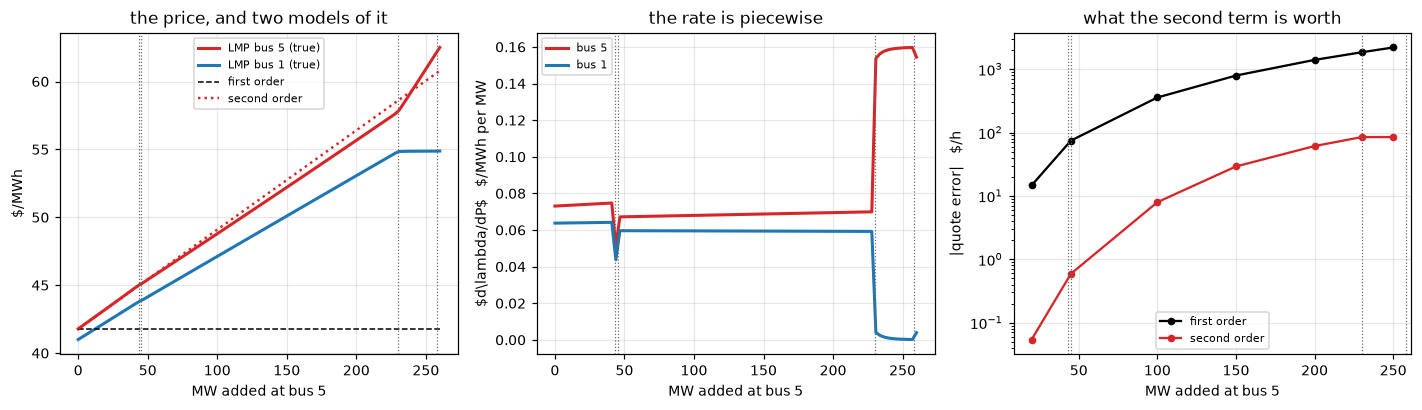

In [14]:
GRID = np.linspace(D0, D0 + SPAN, 90)
SW = [solve(d) for d in GRID]
L5 = np.array([lmp(i, r, 4) for _, i, r in SW])
L1 = np.array([lmp(i, r, 0) for _, i, r in SW])
R5 = np.array([dlmp_dP(s, 4) for s, _, _ in SW])
R1 = np.array([dlmp_dP(s, 0) for s, _, _ in SW])

fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
dd = GRID - D0

ax[0].plot(dd, L5, "C3", lw=2.0, label=r"LMP bus 5 (true)")
ax[0].plot(dd, L1, "C0", lw=2.0, label=r"LMP bus 1 (true)")
ax[0].plot(dd, L0[4] + np.zeros_like(dd), "k--", lw=1.0, label="first order")
ax[0].plot(dd, L0[4] + DL0[4] * dd, "C3:", lw=1.6, label="second order")
ax[0].set_ylabel("$/MWh"); ax[0].set_title("the price, and two models of it")
ax[0].legend(fontsize=7)

ax[1].plot(dd, R5, "C3", lw=2.0, label=r"bus 5")
ax[1].plot(dd, R1, "C0", lw=2.0, label=r"bus 1")
ax[1].set_ylabel(r"$d\lambda/dP$   $/MWh per MW")
ax[1].set_title("the rate is piecewise")
ax[1].legend(fontsize=7)

err_lin  = [abs(L0[4] * g - TRUE[g]) for g in TARGETS]
err_quad = [abs(L0[4] * g + 0.5 * DL0[4] * g * g - TRUE[g]) for g in TARGETS]
ax[2].semilogy(TARGETS, err_lin, "ko-", ms=4, label="first order")
ax[2].semilogy(TARGETS, err_quad, "C3o-", ms=4, label="second order")
ax[2].set_ylabel("|quote error|   $/h")
ax[2].set_title("what the second term is worth")
ax[2].legend(fontsize=7)

for a in ax:
    a.set_xlabel("MW added at bus 5")
    for load, what, _ in EV:
        a.axvline(load - D0, color="0.4", lw=0.8, ls=":")
fig.tight_layout()

## 11. This is not a rival to the delta planning vector

Notebook 41 builds $\mathrm dx^\star/\mathrm dp$ — the delta planning vector,
what to *change* when a parameter moves. It is natural to ask what the dual
quantity adds, and the answer is not that it is better. **It is the other half
of the same vector**, already paid for.

`column(pin)` returns one derivative of the whole KKT solution. Its `x`-block
entries are notebook 41's delta plan; its multiplier entries are this
notebook's price derivatives. One back-solve produces both, and the session
caches it, so reading the second costs nothing once the first has been read.

In [15]:
t = time.perf_counter(); c = sess0.column(0); t_first = time.perf_counter() - t
t = time.perf_counter(); c = sess0.column(0); t_again = time.perf_counter() - t
print(f"column(0): {len(c)} entries, {t_first*1e3:.2f} ms the first time, "
      f"{t_again*1e6:.1f} us cached\n")

print(f"the SAME vector, read two ways:\n")
print(f"  {'notebook 41 -- the x block':<32s}  {'this notebook -- the mult block':<32s}")
print(f"  {'what to change':<32s}  {'what it is worth':<32s}")
print(f"  {'-' * 32}  {'-' * 32}")
prim = [("Pg1", "MW/MW"), ("Pg2", "MW/MW"), ("V5", "pu/MW")]
dual = [0, 1, 4]
for (nm, u), bus in zip(prim, dual):
    p = float(c[sess0.primal_row(sess0.var_entry(nm), nm)]) / BASE
    d = -float(c[sess0.mult_entry(f"pbal{bus+1}")]) / BASE / BASE
    print(f"  {'d' + nm + '/dP':<8s} = {p:+9.6f} {u:<6s}      "
          f"  dLMP{bus + 1}/dP = {d:+9.6f} $/MWh/MW")

nx = len(sess0.var_names) - 1                # th1 was removed as fixed
print(f"\none factorization, one back-solve, {len(c)} entries: {nx} in the x block,")
print(f"{len(ROWS)} multipliers, and the barrier blocks. The question is which half")
print("answers yours --")
print("  'what do I change?'                  -> the x block    (notebook 41)")
print("  'what is it worth, and for how long?' -> the mult block (here)")

column(0): 93 entries, 0.02 ms the first time, 12.3 us cached

the SAME vector, read two ways:

  notebook 41 -- the x block        this notebook -- the mult block 
  what to change                    what it is worth                
  --------------------------------  --------------------------------
  dPg1/dP  = +0.006377 MW/MW         dLMP1/dP = +0.063775 $/MWh/MW
  dPg2/dP  = +0.003816 MW/MW         dLMP2/dP = +0.064864 $/MWh/MW
  dV5/dP   = -0.000064 pu/MW         dLMP5/dP = +0.073089 $/MWh/MW

one factorization, one back-solve, 93 entries: 16 in the x block,
23 multipliers, and the barrier blocks. The question is which half
answers yours --
  'what do I change?'                  -> the x block    (notebook 41)
  'what is it worth, and for how long?' -> the mult block (here)


### The honest scorecard against re-solving on a grid

What this notebook actually competes with is a planner sweeping load on a grid
and reading the answers off. Measured on this model, that comparison is **not**
about accuracy of the slope — a central difference of the LMP here is good to
eight digits, and even one deliberately straddling the first breakpoint is off
by under 2%. Anyone claiming finite differences are too noisy for this should
check it on their own model first; on this one they are fine.

What the grid genuinely cannot do is below.

In [16]:
FIRST = T_PG5 - D0                    # the nearest breakpoint, G3 starting up
print(f"--- central differences of LMP5, first breakpoint at +{FIRST:.1f} MW ---")
print(f"{'h (MW)':>9s}{'central FD':>13s}{'analytic':>12s}{'rel err':>10s}{'straddles':>11s}")
for hh in [1.0, 20.0, 40.0, 45.0, 60.0]:
    fd = (lmp(*solve(D0 + hh)[1:], 4) - lmp(*solve(D0 - hh)[1:], 4)) / (2 * hh)
    print(f"{hh:9.1f}{fd:+13.6f}{DL0[4]:+12.6f}{abs(fd - DL0[4]) / abs(DL0[4]):10.2%}"
          f"{('yes' if hh > FIRST else 'no'):>11s}")

SCORE = [
    ("the slope dlam/dP",                "fine, 8 digits",         "fine, 8 digits"),
    ("where that slope stops holding",   "bisection, 50 solves",   "free, same back-solve"),
    ("WHAT ends it",                     "not available, any cost", "named: Pg2"),
    ("a limit written as a row",         "indistinguishable",      "kind='constraint'"),
    ("a constraint that RELEASES",       "invisible unless watched",
                                         f"predicted, {abs(pred - E3) / E3:.1%} off"),
    ("a regime 1.9 MW wide",             "no grid sample in it",   "both edges located"),
    ("the answer between grid points",   "interpolation",          "closed form"),
    ("the whole picture",                f"{len(GRID)} solves",
                                         "1 solve + 1 back-solve"),
]
w1, w2, w3 = 32, 26, 23
print(f"\n{'scorecard':<{w1}}{'grid of re-solves':<{w2}}{'held factor':<{w3}}")
print(f"{'-' * (w1 - 2):<{w1}}{'-' * (w2 - 2):<{w2}}{'-' * (w3 - 2):<{w3}}")
for a, b, cc in SCORE:
    print(f"{a:<{w1}}{b:<{w2}}{cc:<{w3}}")

print(f"\ntotal solves in this notebook: {NSOLVES}, almost all of them spent")
print("bisecting and sweeping to CHECK the cheap answers, not to produce them.")

--- central differences of LMP5, first breakpoint at +43.4 MW ---
   h (MW)   central FD    analytic   rel err  straddles
      1.0    +0.073089   +0.073089     0.00%         no
     20.0    +0.073092   +0.073089     0.00%         no
     40.0    +0.073099   +0.073089     0.01%         no
     45.0    +0.072684   +0.073089     0.55%        yes
     60.0    +0.071764   +0.073089     1.81%        yes

scorecard                       grid of re-solves         held factor            
------------------------------  ------------------------  ---------------------  
the slope dlam/dP               fine, 8 digits            fine, 8 digits         
where that slope stops holding  bisection, 50 solves      free, same back-solve  
WHAT ends it                    not available, any cost   named: Pg2             
a limit written as a row        indistinguishable         kind='constraint'      
a constraint that RELEASES      invisible unless watched  predicted, 1.8% off    
a regime 1.9 MW wide   

## 12. What the study is actually quoting

Back to the interconnection agreement. Three numbers for 250 MW at bus 5:

In [17]:
g = 250.0
sf, i_f, r_f = solve(D0 + g)
lin, quad = L0[4] * g, L0[4] * g + 0.5 * DL0[4] * g * g
print(f"{'first-order quote  lam5 * dP':<38s}${lin:12,.1f}/h   {(lin/TRUE[g]-1):+7.1%}")
print(f"{'second-order quote  + 0.5 dlam/dP dP^2':<38s}${quad:12,.1f}/h   {(quad/TRUE[g]-1):+7.1%}")
print(f"{'true, by re-solve':<38s}${TRUE[g]:12,.1f}/h")
print(f"\nannualized at 8760 h, the first-order quote is short by "
      f"${(TRUE[g] - lin) * 8760 / 1e6:,.1f}M/yr;")
print(f"the second-order one is over by ${abs(TRUE[g] - quad) * 8760 / 1e6:,.1f}M/yr.")
print(f"\nand the price the new load actually faces at the end of the ramp:")
print(f"  LMP at bus 5   {L0[4]:.2f}  ->  {lmp(i_f, r_f, 4):.2f} $/MWh")
print(f"  LMP at bus 1   {L0[0]:.2f}  ->  {lmp(i_f, r_f, 0):.2f} $/MWh")
print(f"  congestion spread across the network: "
      f"{lmp(i_f, r_f, 4) - lmp(i_f, r_f, 0):.2f} $/MWh")

first-order quote  lam5 * dP          $    10,446.8/h    -17.4%
second-order quote  + 0.5 dlam/dP dP^2$    12,730.8/h     +0.7%
true, by re-solve                     $    12,646.1/h

annualized at 8760 h, the first-order quote is short by $19.3M/yr;
the second-order one is over by $0.7M/yr.

and the price the new load actually faces at the end of the ramp:
  LMP at bus 5   41.79  ->  60.92 $/MWh
  LMP at bus 1   41.00  ->  54.87 $/MWh
  congestion spread across the network: 6.05 $/MWh


## Summary

* An LMP is the shadow price of a bus's power balance, and like every shadow
  price it is a derivative with a **range**. Quoting it as a constant over a
  250 MW interconnection understates the cost by 17%.
* $\mathrm d\lambda/\mathrm dP$ comes from the same back-solve that produces
  the price, through `column(pin)` and `mult_entry(row)`. It agrees with a
  central difference to eight digits at every bus, and the quadratic value
  model it defines removes 96% of the first-order error.
* The rate is **piecewise**, and each piece ends at an active-set change of a
  different kind: a bound releasing (G3 starting up, 0.68x), a bound
  activating (G2 at its rating, 1.32x), a **constraint row** activating (a
  line at its thermal limit, 2.20x), and a bound releasing again (a voltage
  leaving its ceiling). At the line the network splits into two pricing
  regions and bus 1's price stops moving altogether.
* The first two sit **1.9 MW apart**, and between them three generators are
  marginal at once and the price moves 32% slower than anywhere nearby. No
  practical sweep grid puts a sample inside a window that wide; the walk
  returns both of its edges.
* `solution_report` locates the next breakpoint and **names** it from one
  back-solve. It is 0.4 MW short here, and the reason is not nonlinearity —
  it is a single ratio test extrapolating through the release that happens on
  the way. `active_set_changes` walks the same direction on the same factor,
  re-forms at each breakpoint, and lands within 0.03 MW. A limit written as a
  constraint row reads `kind='constraint'`; a release reads `action='leaves'`,
  and a primal ratio test reports neither.
* Every AC-OPF fixes its slack-bus angle, so the factor's index space is
  permanently offset from the model's. Route every factor index through
  `primal_row`; `var_entry` alone returns the neighbouring variable's answer
  and looks entirely reasonable doing it.
* This is not an alternative to notebook 41's delta planning vector — it is
  the dual half of the same cached column, and which half you read is decided
  by whether you are being asked what to change or what it is worth.

### What this notebook is not evidence about

* **Scale.** Five buses. The argument for a held factor over a grid of
  re-solves gets stronger with size, but nothing here measures a system where
  a single solve is expensive, and the timings above are dominated by Python.
* **Degeneracy.** Every event here is a clean, strictly-active transition. At
  a genuine kink — slack and multiplier both vanishing — `mult_entry` refuses
  rather than returning a number, because the two one-sided derivatives
  differ; notebook 40 section 6 covers that gate and `reduced_row_activity`
  is what it reads.
* **Multiple parameters at once.** One pin, one direction. Marginal values do
  not compose, for the reason notebook 40 section 5 gives, and nothing here
  tests a joint step.
* **Unit commitment.** Every generator here is on. A binary on/off decision is
  not an active-set change of this kind and no amount of this machinery sees
  one coming.